In [1]:
import pandas as pd
df=pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df.head()

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes


In [4]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [6]:
df['Age_mean']=df['Age'].fillna(df['Age'].mean())
df['Monthly_Salary_mean']=df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())

/tmp/ipykernel_1256/3553307258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='City',y='Age',palette='pastel')


Text(0, 0.5, 'Age')

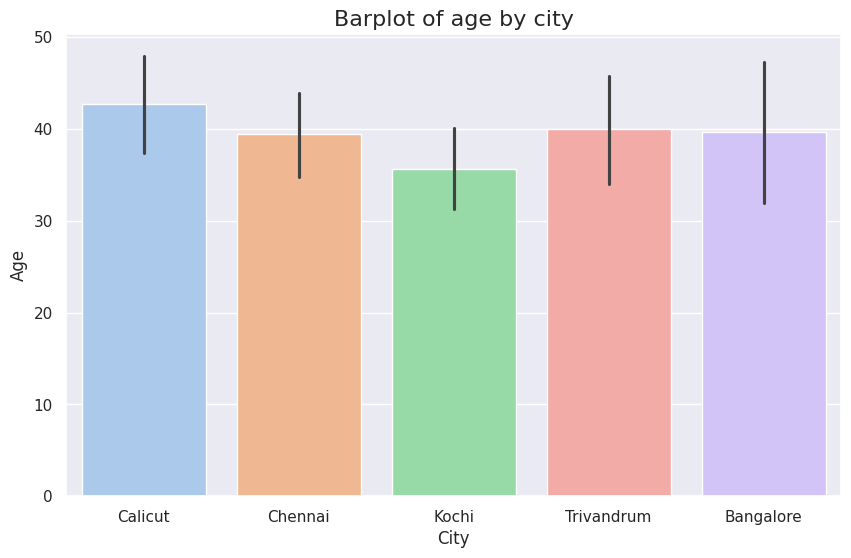

In [9]:
sns.set(style="darkgrid")
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='City',y='Age',palette='pastel')
plt.title('Barplot of age by city',fontsize=16)
plt.xlabel('City',fontsize=12)
plt.ylabel('Age',fontsize=12)

/tmp/ipykernel_1256/484753430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='City',y='Age',palette='pastel')


Text(0, 0.5, 'Age')

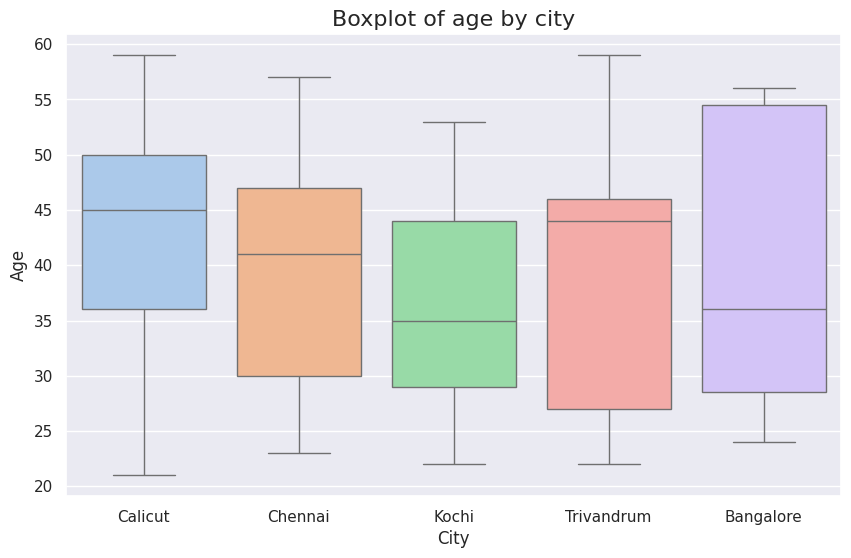

In [12]:
sns.set(style="darkgrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='City',y='Age',palette='pastel')
plt.title('Boxplot of age by city',fontsize=16)
plt.xlabel('City',fontsize=12)
plt.ylabel('Age',fontsize=12)

/tmp/ipykernel_1256/2913515104.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x='City',y='Age',palette='pastel')


Text(0, 0.5, 'Age')

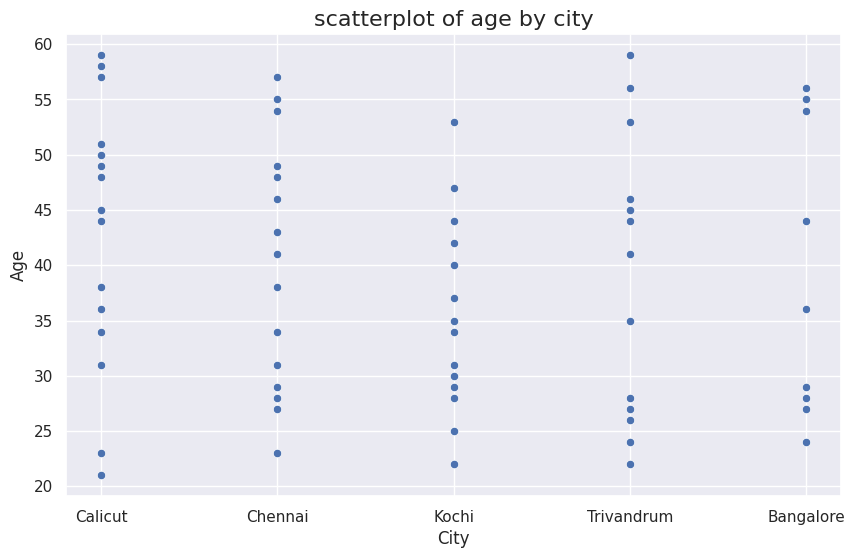

In [13]:
sns.set(style="darkgrid")
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='City',y='Age',palette='pastel')
plt.title('scatterplot of age by city',fontsize=16)
plt.xlabel('City',fontsize=12)
plt.ylabel('Age',fontsize=12)

/tmp/ipykernel_1256/632408618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Department',y='Gender',palette='pastel')


Text(0, 0.5, 'Gender')

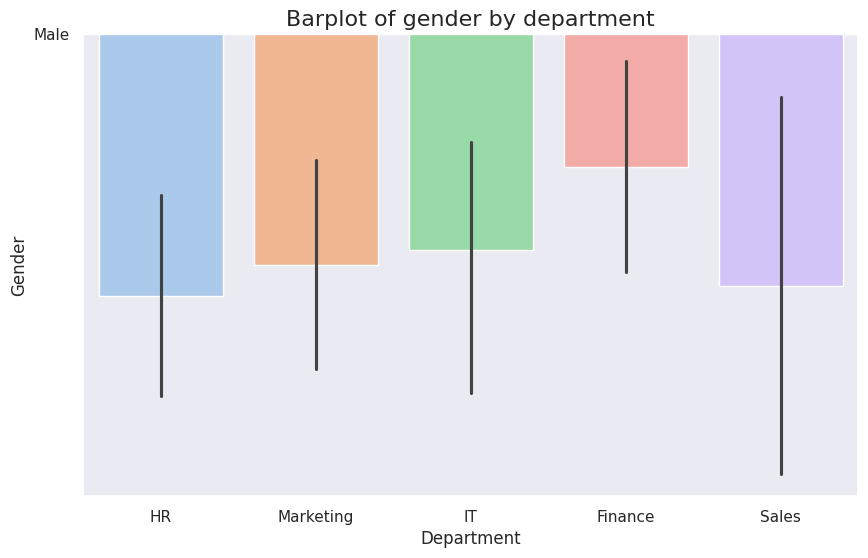

In [19]:
sns.set(style="darkgrid")
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Department',y='Gender',palette='pastel')
plt.title('Barplot of gender by department',fontsize=16)
plt.xlabel('Department',fontsize=12)
plt.ylabel('Gender',fontsize=12)

/tmp/ipykernel_1256/3589886495.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df,x='Experience_Years',y='Monthly_Salary',palette='pastel')


Text(0, 0.5, 'Montghly_Salary')

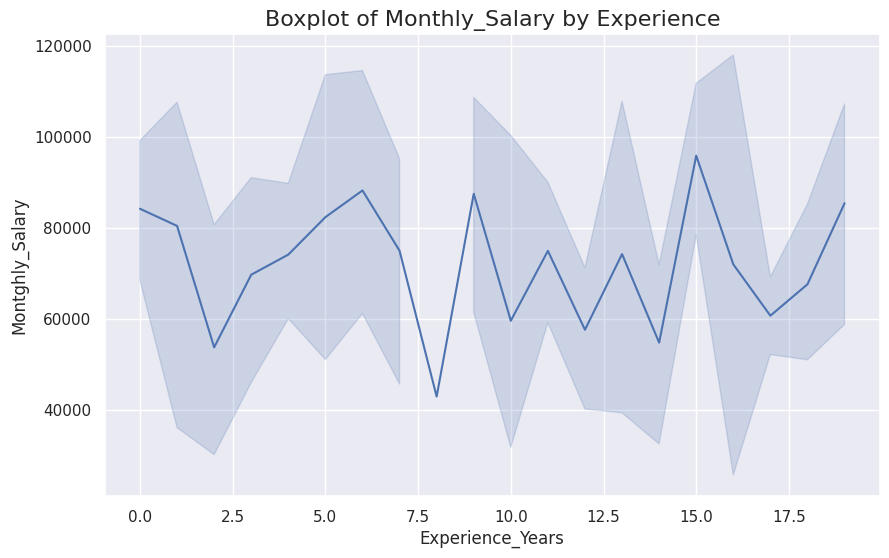

In [21]:
sns.set(style="darkgrid")
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x='Experience_Years',y='Monthly_Salary',palette='pastel')
plt.title('Boxplot of Monthly_Salary by Experience',fontsize=16)
plt.xlabel('Experience_Years',fontsize=12)
plt.ylabel('Montghly_Salary',fontsize=12)

In [26]:
from sklearn.preprocessing import LabelEncoder
encoded_data=df.copy()
label_encoder=LabelEncoder()
encoded_data['Gender_Label']=label_encoder.fit_transform(encoded_data['Gender'])
one_hot_encoded=pd.get_dummies(encoded_data['Department'],prefix='Department')
encoded_data=pd.concat([encoded_data,one_hot_encoded],axis=1)
performance_mapping={1:'One',2:'Two',3:'Three',4:'Four',5:"Five"}
encoded_data['Performance_Rating_cat']=encoded_data['Performance_Rating'].map(performance_mapping)
print(encoded_data[['Gender','Gender_Label','Department','Performance_Rating','Performance_Rating_cat']].head())

   Gender  Gender_Label Department  Performance_Rating Performance_Rating_cat
0    Male             1         HR                   5                   Five
1  Female             0  Marketing                   2                    Two
2  Female             0         HR                   1                    One
3  Female             0         HR                   2                    Two
4    Male             1         IT                   3                  Three


In [30]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
numerical_columns=['Age','Monthly_Salary','Performance_Rating']
encoded_data.dropna(subset=numerical_columns,inplace=True)
minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()

In [37]:
encoded_data['Age_MinMax']=minmax_scaler.fit_transform(encoded_data[['Age']])
encoded_data['Montghly_Salary_MinMax']=minmax_scaler.fit_transform(encoded_data[['Monthly_Salary']])
encoded_data['Performance_Rating_MinMax']=minmax_scaler.fit_transform(encoded_data[['Performance_Rating']])
encoded_data['Gender_MinMax']=minmax_scaler.fit_transform(encoded_data[['Gender_Label']])

In [38]:
encoded_data['Age_Standard']=standard_scaler.fit_transform(encoded_data[['Age']])
encoded_data['Montghly_Salary_Standard']=standard_scaler.fit_transform(encoded_data[['Monthly_Salary']])
encoded_data['Performance_Rating_Standard']=standard_scaler.fit_transform(encoded_data[['Performance_Rating']])
encoded_data['Gender_Standard']=standard_scaler.fit_transform(encoded_data[['Gender_Label']])

In [34]:
df['City_mode']=df['City'].fillna(df['City'].mode()[0])

In [35]:
df.head()

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,Age_mean,Monthly_Salary_mean,City_mode
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,59.0,52350.0,Calicut
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,49.0,118008.0,Chennai
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,35.0,119297.0,Kochi
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,28.0,50351.0,Trivandrum
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,41.0,113668.0,Trivandrum
